In [27]:
import requests
import pandas as pd
import json

# 1. API 설정
api_key = "91b89db582a8b4e32560db475314eadfb1d2cd6aa256a914a381aa06e0d7cb4e"
url = "http://apis.data.go.kr/B552584/ArpltnInforInqireSvc/getCtprvnRltmMesureDnsty"

params = {
    'serviceKey' : api_key,
    'returnType' : 'json',
    'numOfRows' : '500',
    'pageNo' : '1',
    'sidoName' : '광주',
    'ver' : '1.0'
}

# 2. API 호출 및 JSON 파싱
response = requests.get(url, params=params)
data = json.loads(response.text)

# 3. DataFrame으로 변환
items = data['response']['body']['items']
df = pd.DataFrame( items )
df.head()
df.columns

Index(['so2Grade', 'coFlag', 'khaiValue', 'so2Value', 'coValue', 'pm25Flag',
       'pm10Flag', 'o3Grade', 'pm10Value', 'khaiGrade', 'pm25Value',
       'sidoName', 'no2Flag', 'no2Grade', 'o3Flag', 'pm25Grade', 'so2Flag',
       'dataTime', 'coGrade', 'no2Value', 'stationName', 'pm10Grade',
       'o3Value'],
      dtype='object')

In [8]:
import pprint
pprint.pprint(data)

{'response': {'body': {'items': [{'coFlag': None,
                                  'coGrade': '1',
                                  'coValue': '0.5',
                                  'dataTime': '2026-03-06 14:00',
                                  'khaiGrade': '2',
                                  'khaiValue': '66',
                                  'no2Flag': None,
                                  'no2Grade': '1',
                                  'no2Value': '0.010',
                                  'o3Flag': None,
                                  'o3Grade': '2',
                                  'o3Value': '0.049',
                                  'pm10Flag': None,
                                  'pm10Grade': '1',
                                  'pm10Value': '40',
                                  'pm25Flag': None,
                                  'pm25Grade': '1',
                                  'pm25Value': '17',
                                  'sidoName': '광주',


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   dataTime     13 non-null     datetime64[ns]
 1   stationName  13 non-null     object        
 2   pm10Value    13 non-null     int64         
 3   pm25Value    13 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 548.0+ bytes


In [3]:
# df.head()

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# 1. 필요한 컬럼만 추출 (측정일시, 측정소명, 미세먼지, 초미세먼지)
df = df[['dataTime','stationName','pm10Value','pm25Value']]
print("=== 컬럼 추출 후 데이터 ===\n", df, "\n")

# 2. 데이터 타입 변환 (문자열 -> 숫자형 및 날짜형)
# API에서 통신 오류 등으로 '-' 문자가 들어오는 경우가 있어 NaN으로 변환
# raise	오류 발생 (기본값) , ignore	변환 안 하고 그대로 둠 , coerce	NaN으로 변환
df['dataTime'] = pd.to_datetime(df['dataTime'])
df['pm10Value'] = pd.to_numeric(df['pm10Value']) 
df.pm25Value = pd.to_numeric(df.pm25Value)
print("=== 변환 처리 후 ===\n", df, "\n")
# 3. 결측치 처리 (여기서는 단순 제거)
df.isnull().sum()

# 4. 특성 공학 (Feature Engineering)
# 4-1. 시간대, 요일, 월 파생 변수 생성
df['Month'] = df['dataTime'].dt.month
df['Weekday'] = df['dataTime'].dt.dayofweek
df['Time'] = df['dataTime'].dt.time 

# 4-2. 미세먼지(PM10) 등급화 (한국 환경부 기준)
# 0~30: 좋음, 31~80: 보통, 81~150: 나쁨, 151~: 매우나쁨
bins = [0,30,80,150,200]
labels = ['좋음', '보통', '나쁨', '매우나쁨']
df['pm10Value_G'] = pd.cut(df.pm10Value, bins=bins, labels=labels) 



=== 컬럼 추출 후 데이터 ===
             dataTime stationName pm10Value pm25Value
0   2026-03-06 15:00         서석동        38        19
1   2026-03-06 15:00         농성동        34        18
2   2026-03-06 15:00         치평동        37        17
3   2026-03-06 15:00         노대동        39        24
4   2026-03-06 15:00         유촌동        40        16
5   2026-03-06 15:00         두암동        41        23
6   2026-03-06 15:00         운암동        47        20
7   2026-03-06 15:00         건국동        28        20
8   2026-03-06 15:00         일곡동        35        20
9   2026-03-06 15:00         오선동        39        18
10  2026-03-06 15:00     우산동(광주)        42        23
11  2026-03-06 15:00          평동        37        21
12  2026-03-06 15:00         주월동        35        19 

=== 변환 처리 후 ===
               dataTime stationName  pm10Value  pm25Value
0  2026-03-06 15:00:00         서석동         38         19
1  2026-03-06 15:00:00         농성동         34         18
2  2026-03-06 15:00:00         치평동         37  

In [33]:
df.corr

<bound method DataFrame.corr of               dataTime stationName  pm10Value  pm25Value  Month  Weekday  \
0  2026-03-06 15:00:00         서석동         38         19      3        4   
1  2026-03-06 15:00:00         농성동         34         18      3        4   
2  2026-03-06 15:00:00         치평동         37         17      3        4   
3  2026-03-06 15:00:00         노대동         39         24      3        4   
4  2026-03-06 15:00:00         유촌동         40         16      3        4   
5  2026-03-06 15:00:00         두암동         41         23      3        4   
6  2026-03-06 15:00:00         운암동         47         20      3        4   
7  2026-03-06 15:00:00         건국동         28         20      3        4   
8  2026-03-06 15:00:00         일곡동         35         20      3        4   
9  2026-03-06 15:00:00         오선동         39         18      3        4   
10 2026-03-06 15:00:00     우산동(광주)         42         23      3        4   
11 2026-03-06 15:00:00          평동         37         21

- 시각화

<Figure size 1500x900 with 0 Axes>

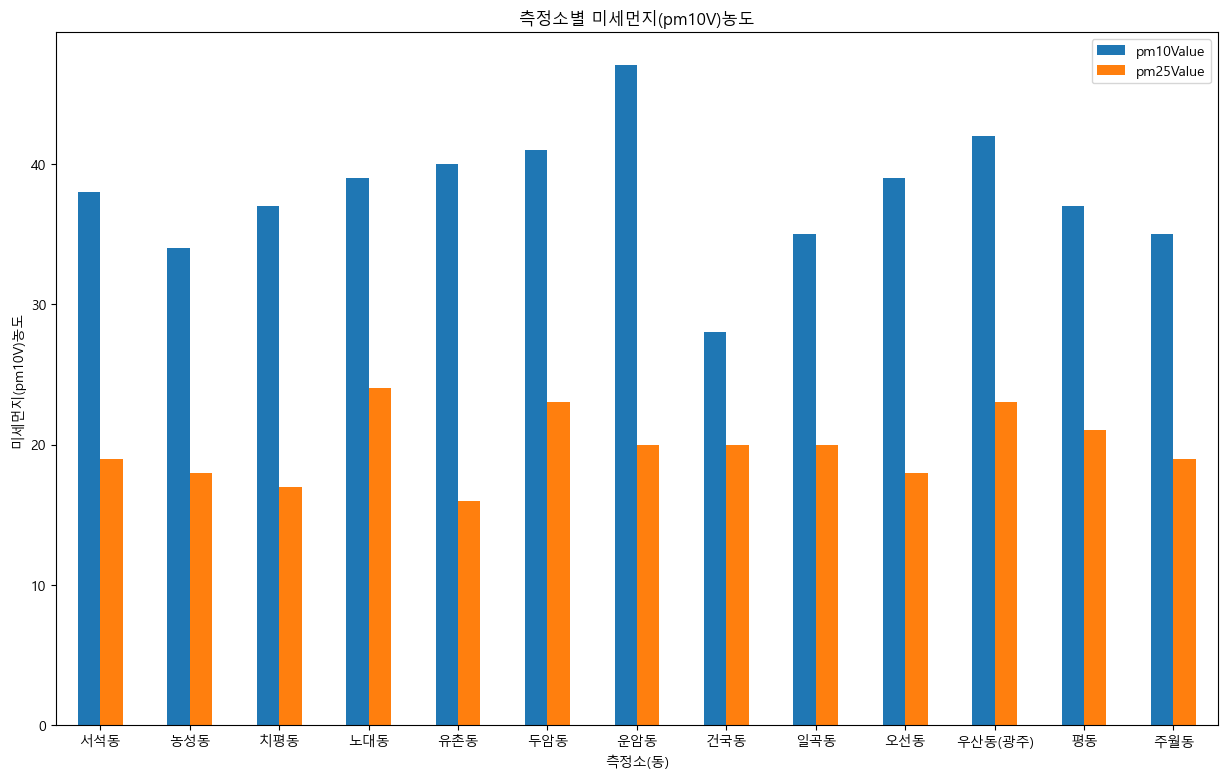

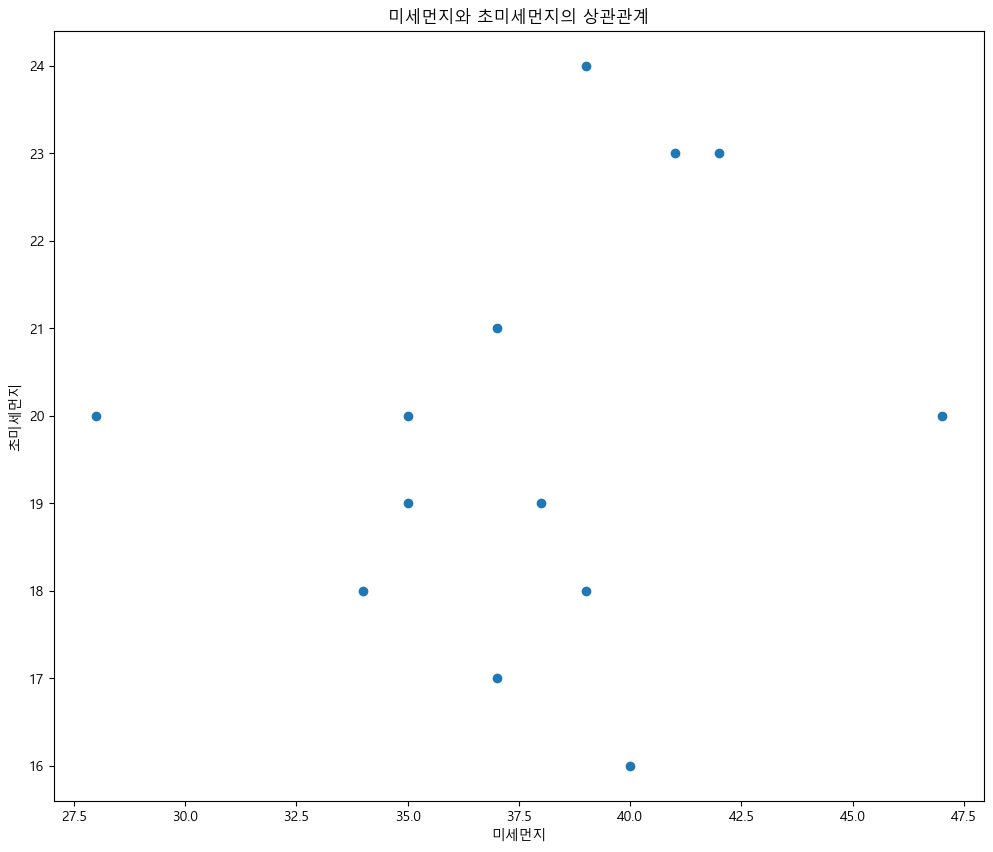

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
# import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 시각화 1: 특정 측정소의 시간별 미세먼지 추이 (Line Plot)
plt.figure(figsize=(15,9))
df.set_index('stationName')[['pm10Value', 'pm25Value']].plot(kind='bar', figsize=(15,9))
plt.title('측정소별 미세먼지(pm10V)농도')
plt.xlabel('측정소(동)')
plt.xticks(rotation=0)
plt.ylabel('미세먼지(pm10V)농도')
plt.show()


# 시각화 2: 서울시 전체 시간대별 평균 미세먼지 농도 (Bar Plot)


# 시각화 3: 미세먼지와 초미세먼지의 상관관계 (Scatter Plot)

plt.figure(figsize=(12,10))
plt.scatter(df.pm10Value, df.pm25Value, label='미세먼지')
plt.title('미세먼지와 초미세먼지의 상관관계')
plt.xlabel('미세먼지')
plt.ylabel('초미세먼지')
plt.show()